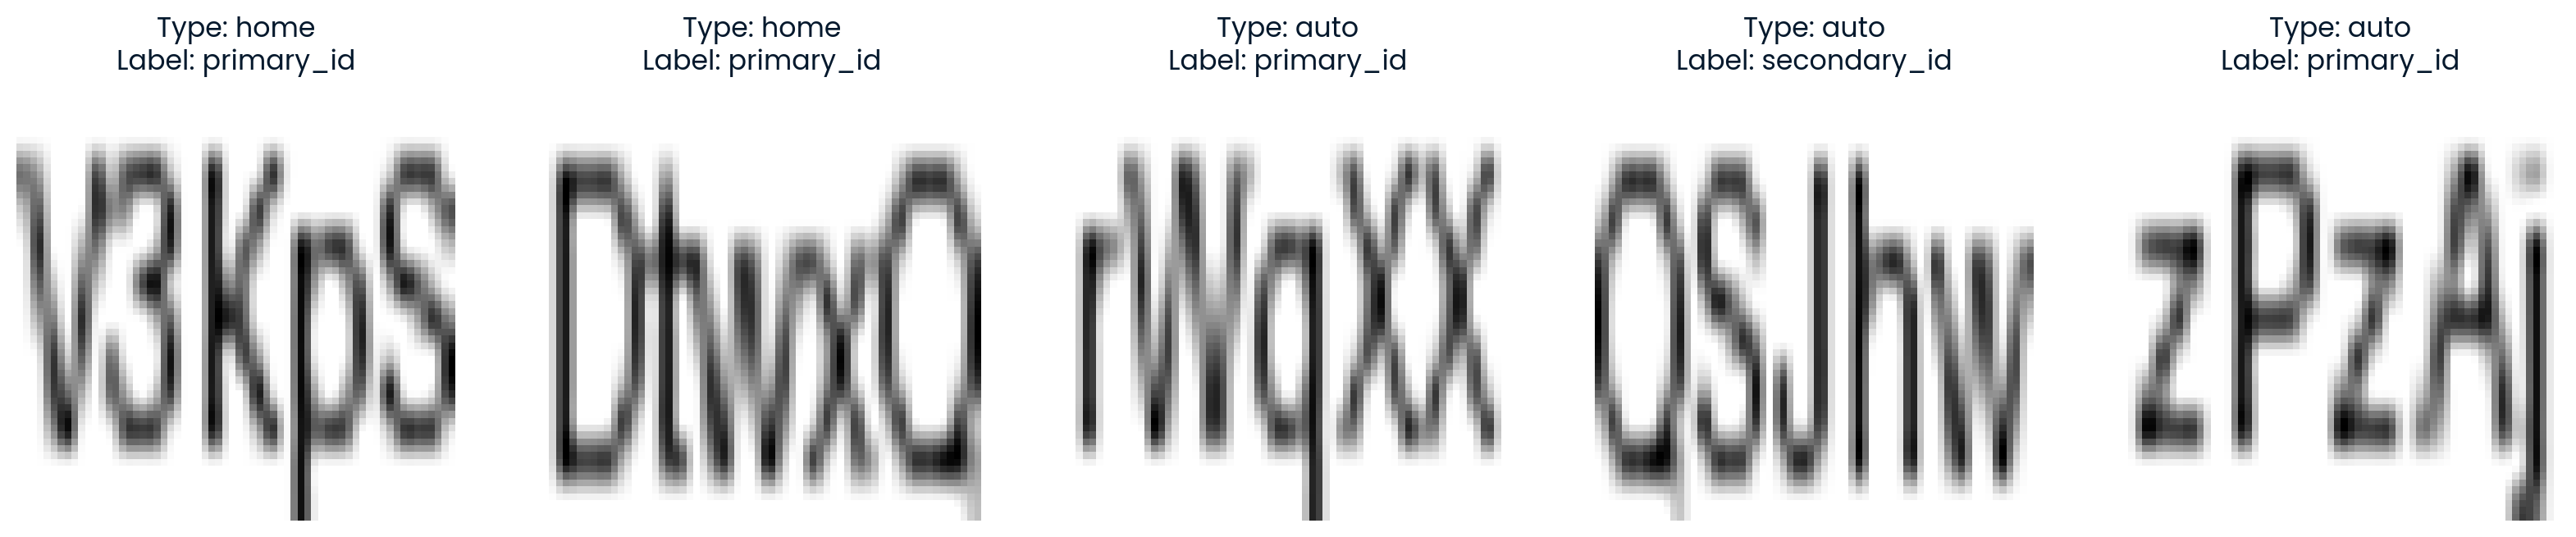

In [1]:

import matplotlib.pyplot as plt
import numpy as np
from project_utils import ProjectDataset
import pickle 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

dataset = pickle.load(open('ocr_insurance_dataset.pkl', 'rb'))

def show_dataset_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, min(num_images, len(dataset)), figsize=(20, 4))
    for ax, idx in zip(axes, np.random.choice(len(dataset), min(num_images, len(dataset)), False)):
        img, lbl = dataset[idx]
        ax.imshow((img[0].numpy() * 255).astype(np.uint8).reshape(64,64), cmap='gray'), ax.axis('off')
        ax.set_title(f"Type: {list(dataset.type_mapping.keys())[img[1].tolist().index(1)]}\nLabel: {list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(lbl)]}")
    plt.show()

show_dataset_images(dataset)

In [3]:
for epoch in range(10):  
    correct = 0
    total = 0
    running_loss = 0

    for (images, types), labels in train_dataloader:
        optimizer.zero_grad()
        outputs = model(images, types)
        loss = criterion(outputs, labels) 
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch 1, Loss: 2.6482, Accuracy: 95.00%
Epoch 2, Loss: 2.2628, Accuracy: 94.00%
Epoch 3, Loss: 2.0745, Accuracy: 94.00%
Epoch 4, Loss: 1.3507, Accuracy: 98.00%
Epoch 5, Loss: 0.9996, Accuracy: 100.00%
Epoch 6, Loss: 0.7352, Accuracy: 100.00%
Epoch 7, Loss: 0.5618, Accuracy: 100.00%
Epoch 8, Loss: 0.7514, Accuracy: 100.00%
Epoch 9, Loss: 0.4084, Accuracy: 100.00%
Epoch 10, Loss: 0.2426, Accuracy: 100.00%


In [4]:
model.eval()

OCRModel(
  (image_layer): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=16384, out_features=128, bias=True)
  )
  (type_layer): Sequential(
    (0): Linear(in_features=5, out_features=10, bias=True)
    (1): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=138, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [5]:
def predict_sample(model, image, type_vector):
    model.eval()
    
    with torch.no_grad():
        image = image.unsqueeze(0)      
        type_vector = type_vector.unsqueeze(0)
        
        output = model(image, type_vector)
        _, predicted = torch.max(output, 1)
        
    return predicted.item()

In [7]:
label_name = list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(prediction)]
actual_name = list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(lbl)]

print(f"Predicted: {label_name}")
print(f"Actual: {actual_name}")

Predicted: primary_id
Actual: primary_id


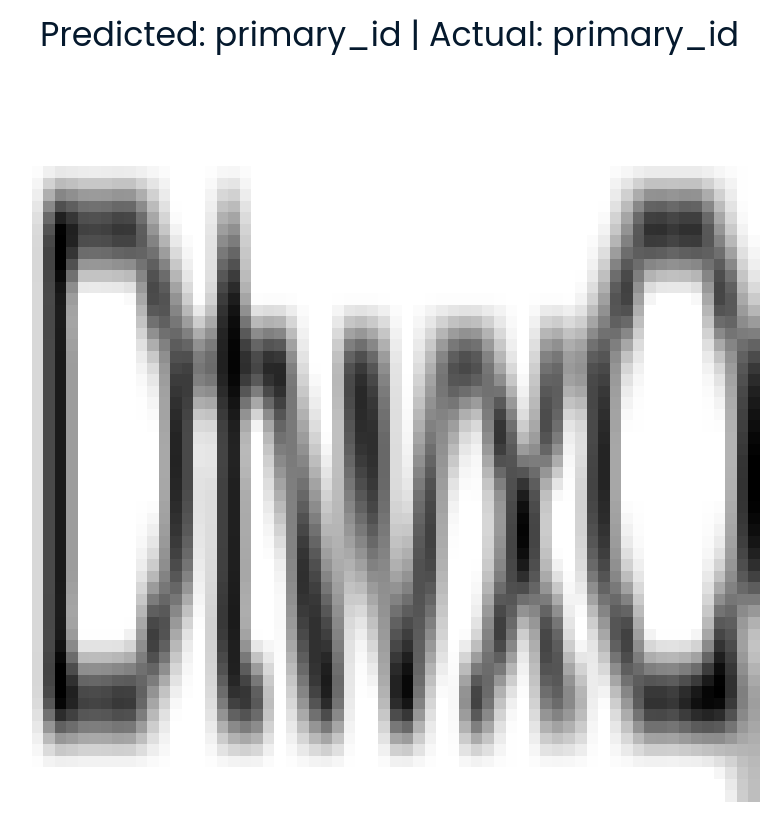

In [8]:
plt.imshow(image.numpy().reshape(64,64), cmap='gray')
plt.title(f"Predicted: {label_name} | Actual: {actual_name}")
plt.axis('off')
plt.show()

In [9]:

custom_image = torch.randn(1, 64, 64)  

custom_type = torch.tensor([1,0,0,0,0]).float()

prediction = predict_sample(model, custom_image, custom_type)

print("Prediction:", prediction)

Prediction: 1
